In [4]:
import pandas as pd

datasets = ['scifact', 'scidocs', 'nfcorpus', 'arguana', 'fiqa']
dataframes = []

for dataset in datasets:
    data = pd.read_csv(f'{dataset}_results.csv')
    data['dataset'] = dataset
    dataframes.append(data)

res_df = pd.concat(dataframes, ignore_index=True)
res_df

,Model,NDCG@1,NDCG@10,Recall@1,Recall@10,Precision@1,Precision@10,dataset
0,redis_BM25,0.47333,0.58671,0.46167,0.70533,0.47333,0.07833,scifact
1,redis_vector,0.49667,0.61986,0.47567,0.74400,0.49667,0.08500,scifact
2,lin_combo,0.52000,0.64888,0.50500,0.78333,0.52000,0.08833,scifact
3,weighted_rrf,0.48667,0.64578,0.46956,0.79667,0.48667,0.09033,scifact
4,rerank,0.46667,0.62705,0.44317,0.82122,0.46667,0.09300,scifact
5,redis_BM25,0.16000,0.13858,0.03245,0.14547,0.16000,0.07160,scidocs
6,redis_vector,0.23100,0.21050,0.04673,0.22517,0.23100,0.11110,scidocs
7,lin_combo,0.20700,0.20333,0.04213,0.22967,0.20700,0.11340,scidocs
8,weighted_rrf,0.20000,0.19013,0.04055,0.20797,0.20000,0.10260,scidocs
9,rerank,0.18100,0.17464,0.03678,0.19917,0.18100,0.09820,scidocs


In [ ]:
precision_pivot = res_df.pivot_table(index='dataset', columns="Model", values=['Precision@1'], aggfunc='mean')
precision_pivot

<Axes: title={'center': 'Precision@1'}, xlabel='dataset'>

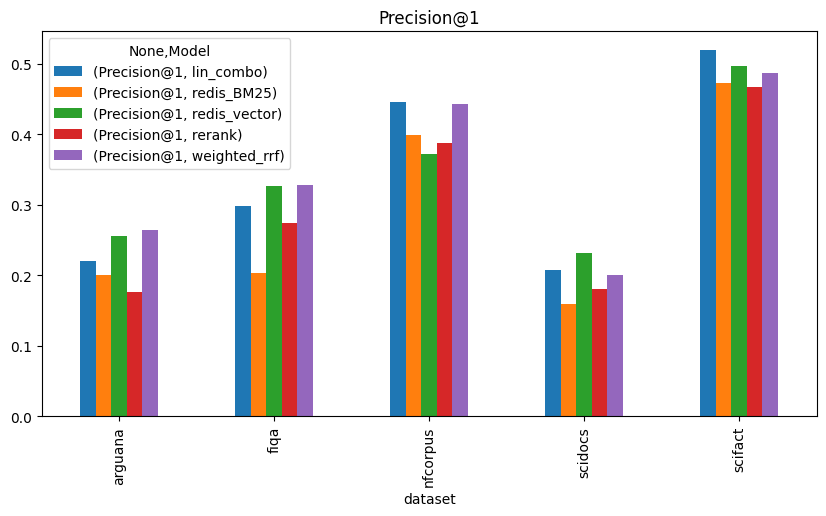

In [40]:
precision_pivot.plot(kind='bar', figsize=(10, 5), title='Precision@1')

In [25]:
recall_pivot = res_df.pivot_table(index='dataset', columns="Model", values=['Recall@10'], aggfunc='mean')
recall_pivot_norm = recall_pivot.copy()
recall_pivot

Recall@10                                              
Model    lin_combo redis_BM25 redis_vector   rerank weighted_rrf
dataset                                                         
arguana    0.76316    0.69203      0.76814  0.76458      0.78450
fiqa       0.41490    0.29653      0.41133  0.43971      0.42786
nfcorpus   0.15499    0.13888      0.12401  0.16290      0.16126
scidocs    0.22967    0.14547      0.22517  0.19917      0.20797
scifact    0.78333    0.70533      0.74400  0.82122      0.79667

<Axes: title={'center': 'Recall@10'}, xlabel='dataset'>

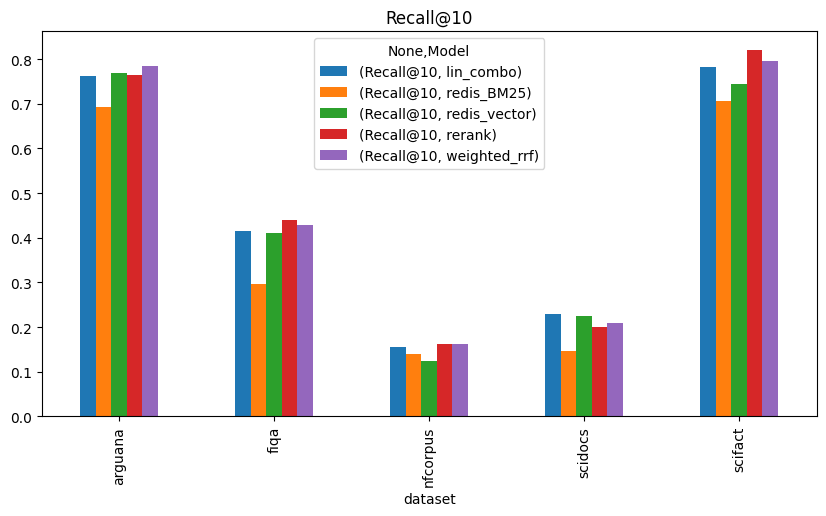

In [41]:
recall_pivot.plot(kind='bar', figsize=(10, 5), title='Recall@10')

In [42]:
ndcg_pivot = res_df.pivot_table(index='dataset', columns="Model", values=['NDCG@10'], aggfunc='mean')
ndcg_pivot

NDCG@10                                              
Model    lin_combo redis_BM25 redis_vector   rerank weighted_rrf
dataset                                                         
arguana    0.47209    0.42870      0.49512  0.42761      0.50243
fiqa       0.32969    0.23083      0.34469  0.32813      0.34911
nfcorpus   0.32395    0.28788      0.27845  0.31588      0.31793
scidocs    0.20333    0.13858      0.21050  0.17464      0.19013
scifact    0.64888    0.58671      0.61986  0.62705      0.64578

<Axes: title={'center': 'NDCG@10'}, xlabel='dataset'>

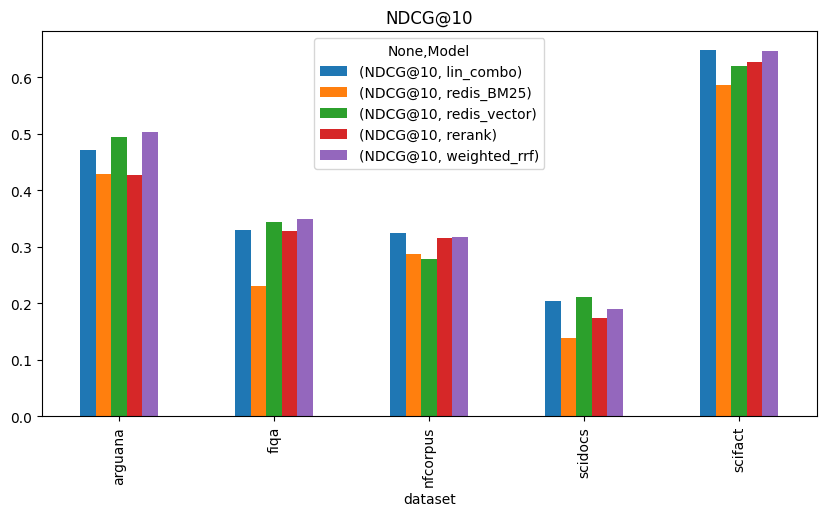

In [43]:
ndcg_pivot.plot(kind='bar', figsize=(10, 5), title='NDCG@10')

In [ ]:
def min_max(row):
    print(row)
    return (row - row.min()) / (row.max() - row.min())

def z_norm(row):
    print(row)
    return (row - row.mean()) / (row.std())

def max_norm(row):
    print(row)
    return row / row.max()

recall_pivot_norm_ = recall_pivot_norm.apply(lambda x: max_norm(x), axis=1)
recall_pivot_norm_.plot(kind='bar', figsize=(10, 5))